In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, mannwhitneyu
import os, warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading real genomap data...
b genomap: (1186, 40, 40, 1) | mono genomap: (1186, 40, 40, 1)

Recomputing _MIN/_MAX from stacked real genomaps (replicates training normalization)...
_MIN = -2.464965  |  _MAX = 34.409313

T_b shape: (1600, 1600) | T_mono shape: (1600, 1600)
num_genes: 1600 | totalGridPoint: 1600

Loading real gene expression CSVs...
real_b_expr: (1186, 1600) | real_mono_expr: (1186, 1600)

Loading generator...


Generating 1186 synthetic b genomaps  (label=-0.5)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step
Generating 1186 synthetic mono genomaps (label=+0.5)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Output 1 — syn_b:   shape=(1186, 40, 40, 1), range=[-0.975, 0.720]
Output 1 — syn_mono: shape=(1186, 40, 40, 1), range=[-0.967, 0.462]
Output 1 saved.

After min-max reversal:
  syn_b range:   [-2.0092, 29.2448]
  syn_mono range: [-1.8537, 24.4822]

OPTION B: Pseudo-inverse Reverse
  projMat: (1600, 1600) | projMat_inv: (1600, 1600)
  projMat: (1600, 1600) | projMat_inv: (1600, 1600)
Option B — syn_b: (1186, 1600) | syn_mono: (1186, 1600)
Option B CSVs saved.

OPTION A: Direct Lookup Reverse
  T shape: (1600, 1600)
  Orientation: (n_positions x n_genes) → argmax along axis=1
  Unique genes assigned: 1600 / 1600
  T shape: (1600, 1600)
  Orientation: (n_positions x n_genes) → argmax along axis=1
  Unique genes assigned: 1600 / 1600
Option A — syn_b: (1186, 1600) | syn_mono: (1186, 1600)
Option A CSV

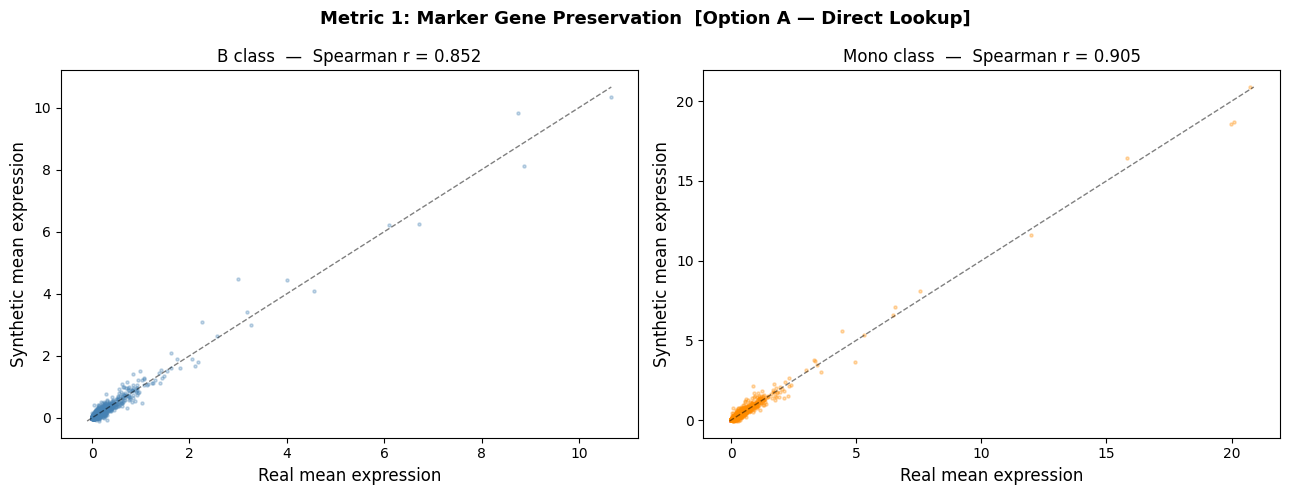


--- Metric 2: Gene-Gene Correlation Consistency ---
  Pearson r of correlation matrices — B:    -0.0061
  Pearson r of correlation matrices — Mono: 0.0180


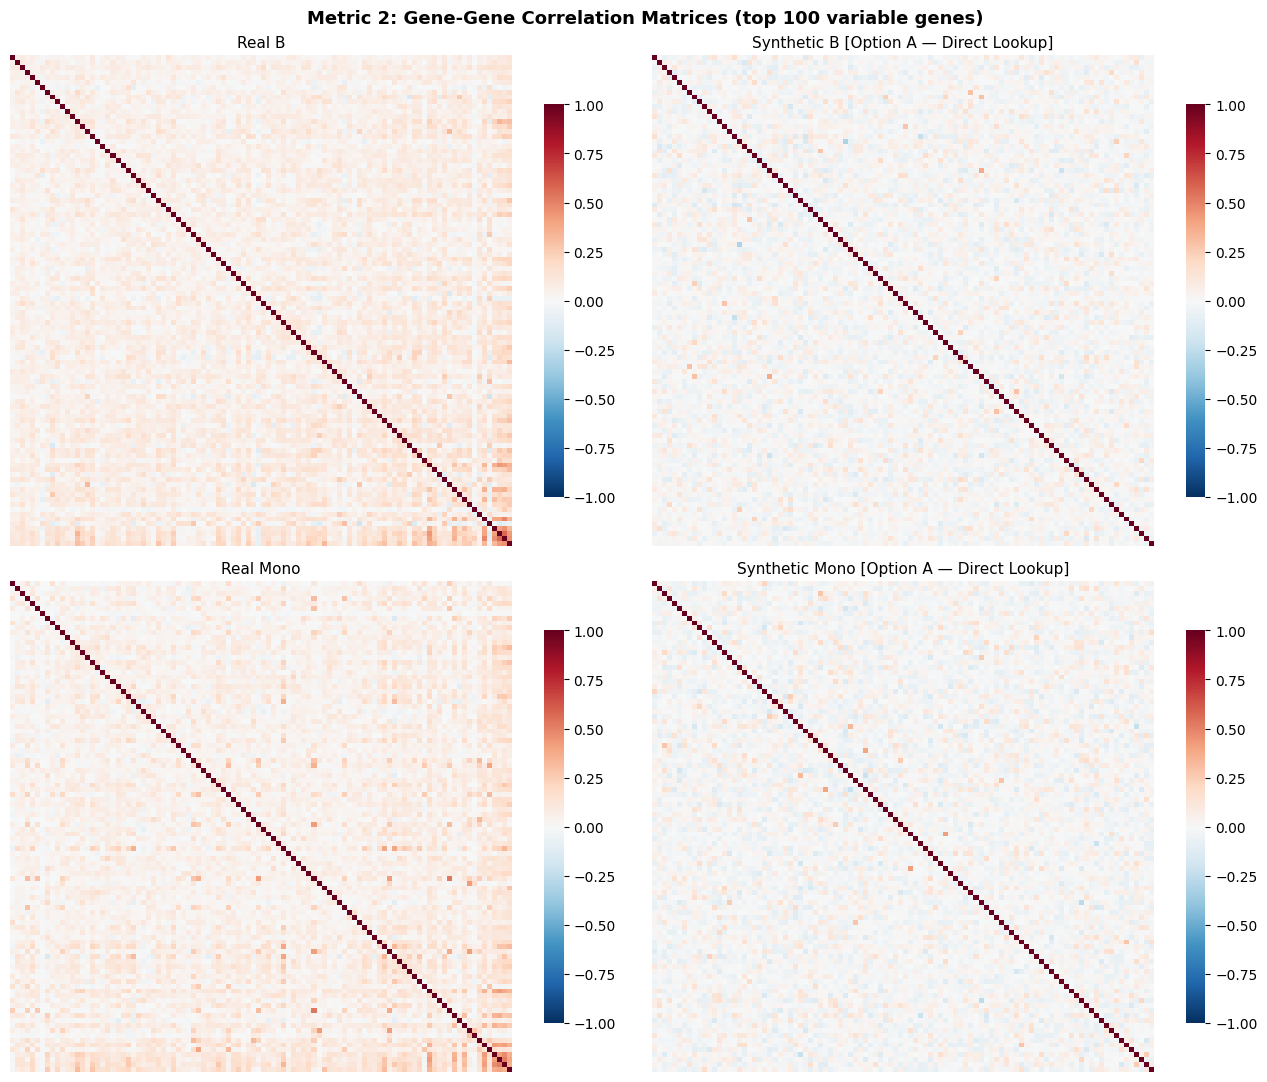

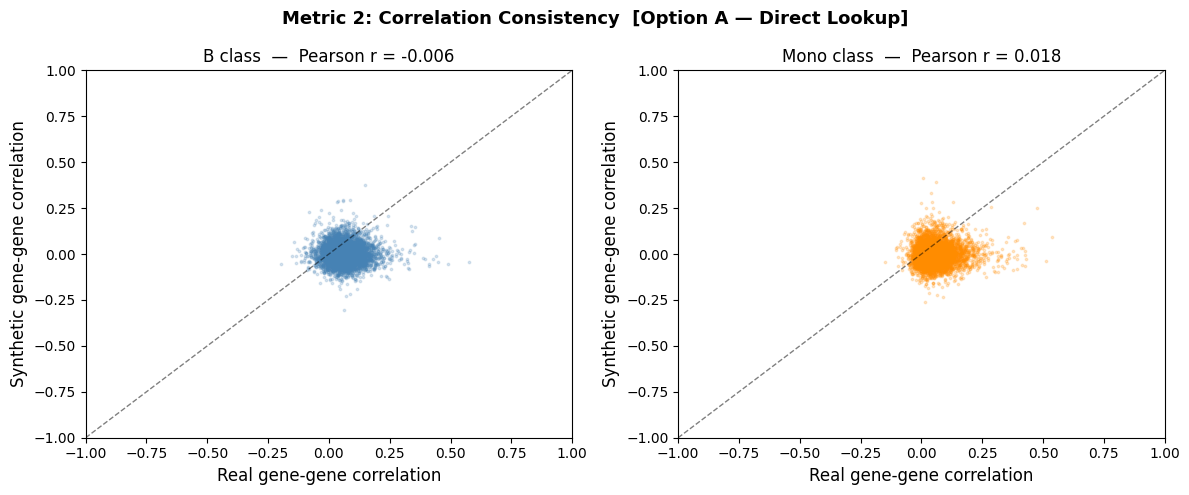


--- Metric 3: Differential Expression Conservation ---
  Running Wilcoxon on real data...
  Running Wilcoxon on synthetic data...
  Spearman r of -log10(p-values): 0.5012  (p=1.59e-102)
  Top-100 DE gene overlap: 56.0%


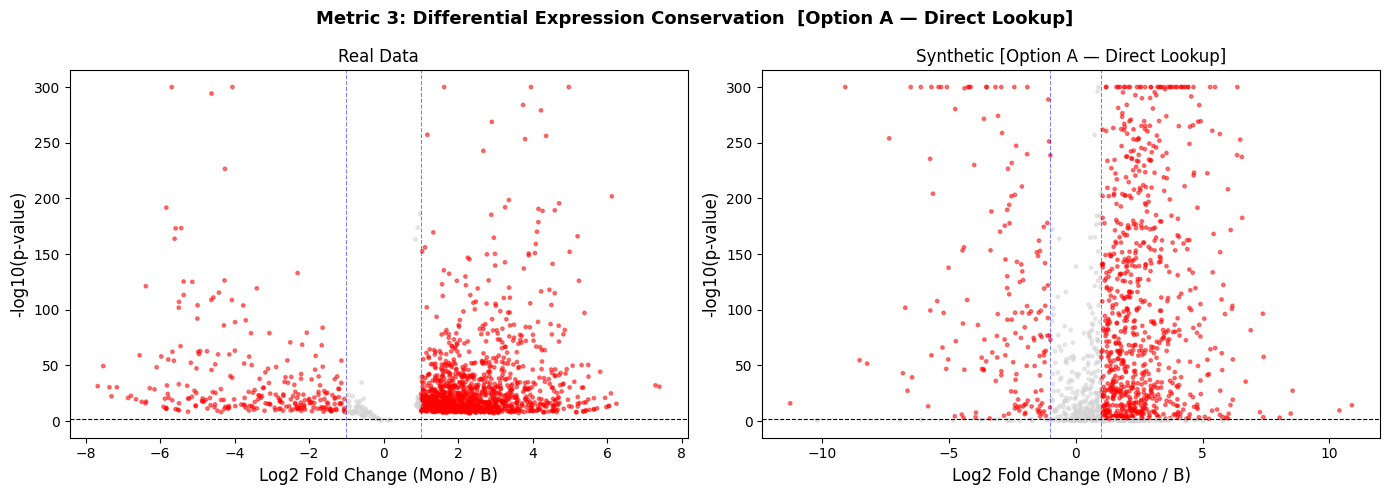

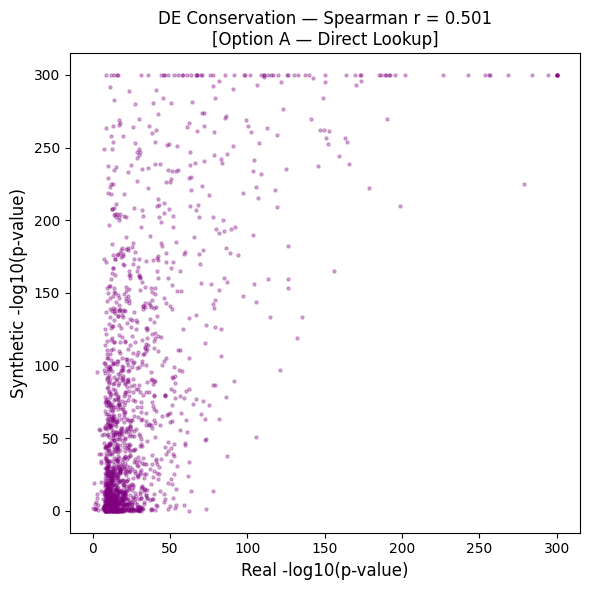


--- Summary: Option A — Direct Lookup ---
  Marker Spearman r   — B: 0.8516  | Mono: 0.9048
  Marker top-50 overlap — B: 80.0%  | Mono: 78.0%
  Corr matrix Pearson r — B: -0.0061  | Mono: 0.0180
  DE Spearman r: 0.5012  | Top-100 overlap: 56.0%

EVALUATION — Option B — Pseudo-inverse

--- Metric 1: Marker Gene Preservation ---
  Spearman r — B class mean expression:    0.8478
  Spearman r — Mono class mean expression: 0.9094
  Top-50 marker overlap — B:    84.0%
  Top-50 marker overlap — Mono: 84.0%


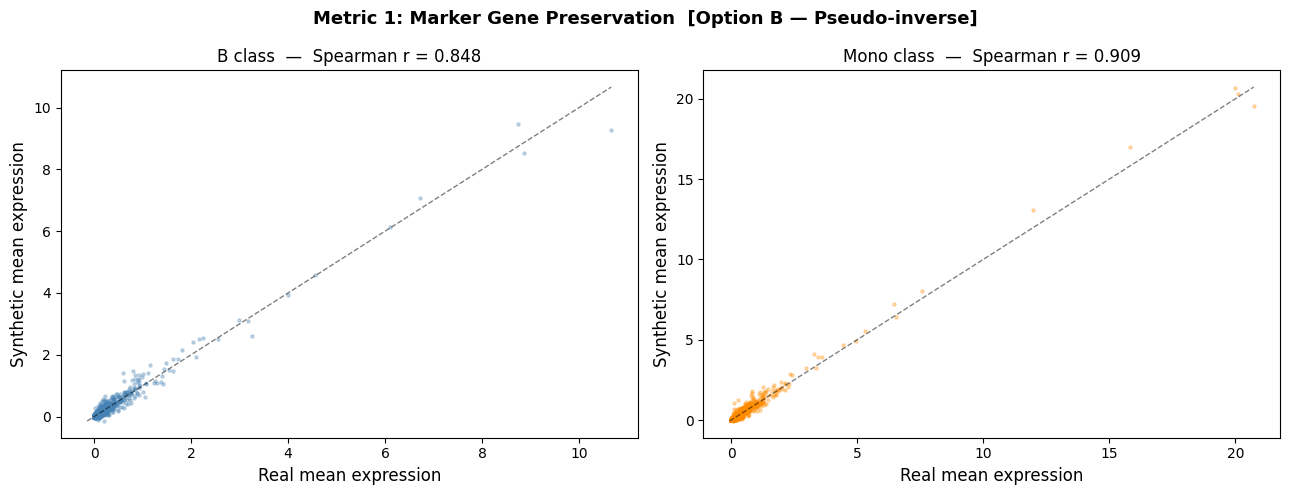


--- Metric 2: Gene-Gene Correlation Consistency ---
  Pearson r of correlation matrices — B:    0.0006
  Pearson r of correlation matrices — Mono: 0.0029


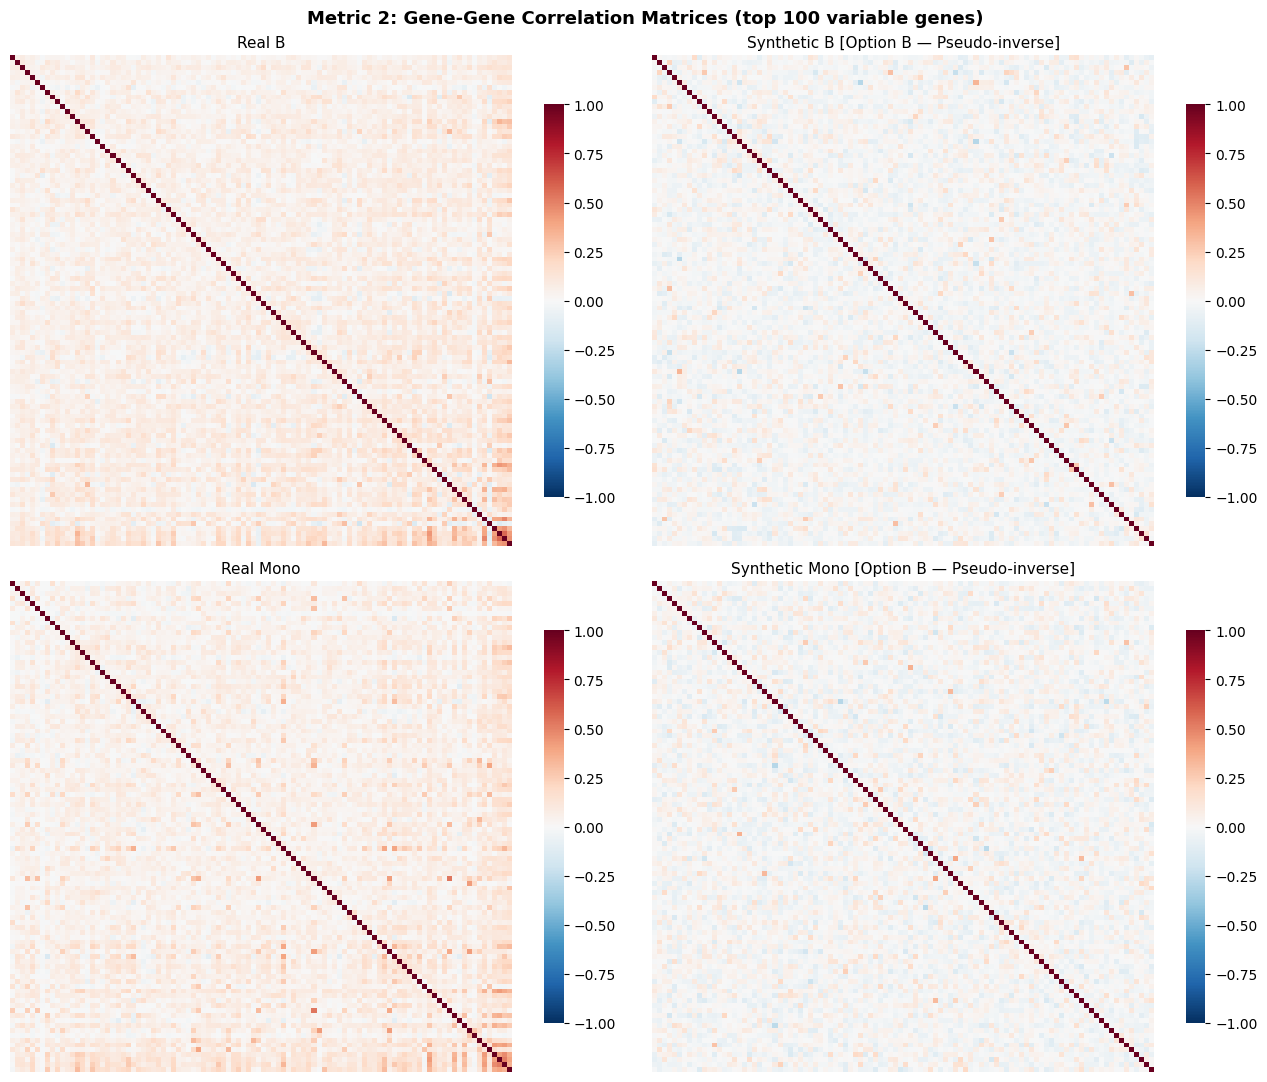

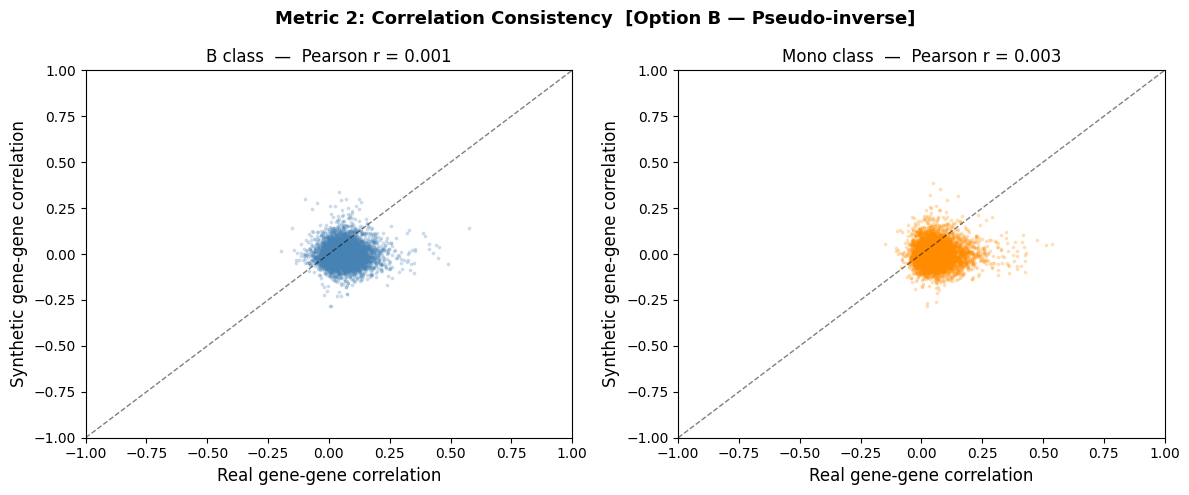


--- Metric 3: Differential Expression Conservation ---
  Running Wilcoxon on real data...
  Running Wilcoxon on synthetic data...
  Spearman r of -log10(p-values): 0.4558  (p=6.98e-83)
  Top-100 DE gene overlap: 60.0%


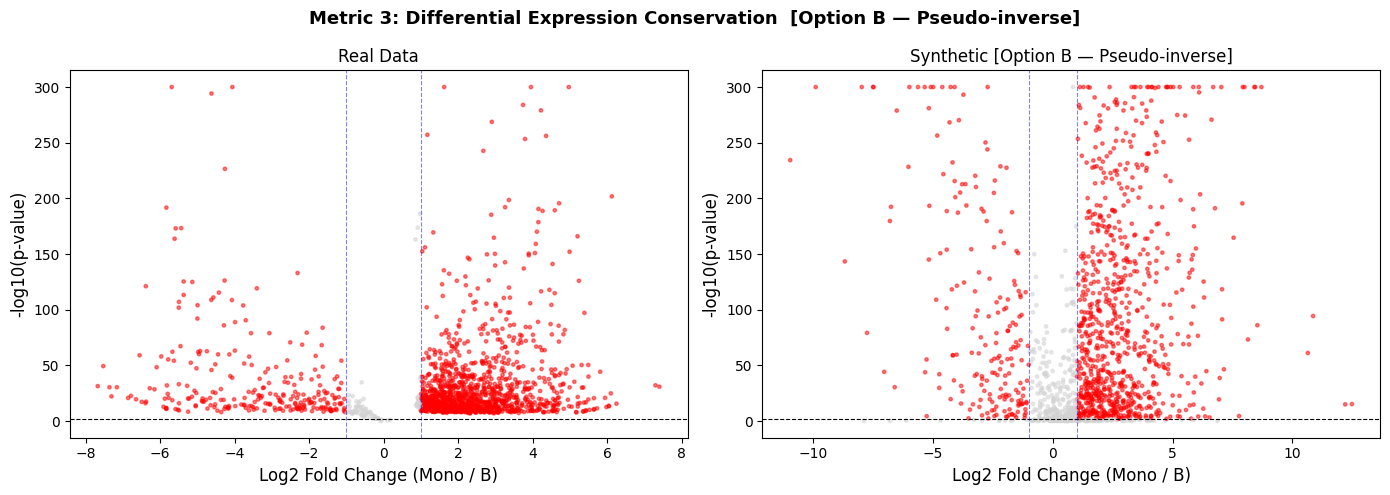

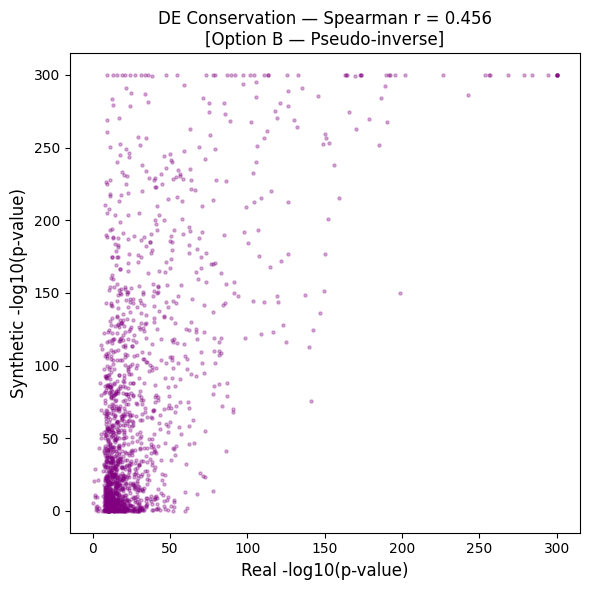


--- Summary: Option B — Pseudo-inverse ---
  Marker Spearman r   — B: 0.8478  | Mono: 0.9094
  Marker top-50 overlap — B: 84.0%  | Mono: 84.0%
  Corr matrix Pearson r — B: 0.0006  | Mono: 0.0029
  DE Spearman r: 0.4558  | Top-100 overlap: 60.0%

FINAL COMPARISON: Option A vs Option B
                         Metric  Option A (Direct Lookup)  Option B (Pseudo-inverse)
         Marker: Spearman r (B)                    0.8516                     0.8478
      Marker: Spearman r (Mono)                    0.9048                     0.9094
   Marker: Top-50 overlap B (%)                   80.0000                    84.0000
Marker: Top-50 overlap Mono (%)                   78.0000                    84.0000
     Corr matrix: Pearson r (B)                   -0.0061                     0.0006
  Corr matrix: Pearson r (Mono)                    0.0180                     0.0029
                 DE: Spearman r                    0.5012                     0.4558
        DE: Top-100 overlap (%)   

In [ ]:
# ============================================================
# SynCellNet — PBMC Reverse Gene Expression + Biological Fidelity
# Option A (Direct Lookup) + Option B (Pseudo-inverse, corrected)
# ============================================================

# ============================================================
# 1. PATHS
# ============================================================
BASE         = '/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset'
REV_DOCS     = BASE + '/Reverse GeneExpression Required Docs'
SAVE_DIR     = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Reverse_PBMC_Biological_Fidelity_Analysis'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR + '/OptionA', exist_ok=True)
os.makedirs(SAVE_DIR + '/OptionB', exist_ok=True)

generator_path    = BASE + '/generator.h5'
b_genomap_path    = BASE + '/b_Class_genomap.npy'
mono_genomap_path = BASE + '/mono_Class_genomap.npy'
b_expr_path       = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PBMC dataset/b_Class_dataset.csv'
mono_expr_path    = '/content/drive/MyDrive/Ahsan/16. Review SynCellNet  work/Dataset/Real PBMC dataset/mono_Class_dataset.csv'

T_b_path          = REV_DOCS + '/transformation_matrix_T_b_class.npy'
T_mono_path       = REV_DOCS + '/transformation_matrix_T_mono_class.npy'
means_b_path      = REV_DOCS + '/original_means_b_class.npy'
means_mono_path   = REV_DOCS + '/original_means_mono_class.npy'
stds_b_path       = REV_DOCS + '/original_stds_b_class.npy'
stds_mono_path    = REV_DOCS + '/original_stds_mono_class.npy'

# ============================================================
# 2. LOAD REAL DATA
# ============================================================
print("Loading real genomap data...")
b_real   = np.load(b_genomap_path).astype(np.float32)
mono_real = np.load(mono_genomap_path).astype(np.float32)

# Ensure 4D: (n, 40, 40, 1)
if b_real.ndim == 3:   b_real   = b_real[..., np.newaxis]
if mono_real.ndim == 3: mono_real = mono_real[..., np.newaxis]
print(f"b genomap: {b_real.shape} | mono genomap: {mono_real.shape}")

# Recompute _MIN and _MAX exactly as training code did
print("\nRecomputing _MIN/_MAX from stacked real genomaps (replicates training normalization)...")
stacked = np.vstack([b_real, mono_real])
_MIN = float(stacked.min())
_MAX = float(stacked.max())
print(f"_MIN = {_MIN:.6f}  |  _MAX = {_MAX:.6f}")

# Load T matrices and stats
T_b    = np.load(T_b_path)
T_mono = np.load(T_mono_path)
means_b    = np.load(means_b_path)
means_mono = np.load(means_mono_path)
stds_b     = np.load(stds_b_path)
stds_mono  = np.load(stds_mono_path)

print(f"\nT_b shape: {T_b.shape} | T_mono shape: {T_mono.shape}")
num_genes      = T_b.shape[1]
image_size     = 40
totalGridPoint = image_size * image_size   # 1600
print(f"num_genes: {num_genes} | totalGridPoint: {totalGridPoint}")

# Load real gene expression (raw values, cells x genes)
print("\nLoading real gene expression CSVs...")
real_b_expr    = pd.read_csv(b_expr_path,    header=None).values.astype(np.float32)
real_mono_expr = pd.read_csv(mono_expr_path, header=None).values.astype(np.float32)
print(f"real_b_expr: {real_b_expr.shape} | real_mono_expr: {real_mono_expr.shape}")

# ============================================================
# 3. GENERATE SYNTHETIC GENOMAPS — OUTPUT 1 (tanh, [-1, 1])
# ============================================================
print("\nLoading generator...")
generator = tf.keras.models.load_model(generator_path)

n_b    = b_real.shape[0]     # 1186
n_mono = mono_real.shape[0]  # 1186
latent_dim = 128

def generate_genomaps(generator, n_samples, label, latent_dim=128, batch_size=64):
    noise  = tf.random.normal(shape=(n_samples, latent_dim))
    labels = np.full((n_samples, 1), label, dtype=np.float32)
    return generator.predict([noise, labels], batch_size=batch_size)

print(f"Generating {n_b} synthetic b genomaps  (label=-0.5)...")
syn_b_tanh   = generate_genomaps(generator, n_b,    label=-0.5)
print(f"Generating {n_mono} synthetic mono genomaps (label=+0.5)...")
syn_mono_tanh = generate_genomaps(generator, n_mono, label=0.5)

print(f"\nOutput 1 — syn_b:   shape={syn_b_tanh.shape}, range=[{syn_b_tanh.min():.3f}, {syn_b_tanh.max():.3f}]")
print(f"Output 1 — syn_mono: shape={syn_mono_tanh.shape}, range=[{syn_mono_tanh.min():.3f}, {syn_mono_tanh.max():.3f}]")

np.save(SAVE_DIR + '/synthetic_b_genomap_tanh.npy',   syn_b_tanh)
np.save(SAVE_DIR + '/synthetic_mono_genomap_tanh.npy', syn_mono_tanh)
print("Output 1 saved.")

# ============================================================
# 4. SHARED: REVERSE MIN-MAX NORMALIZATION
# ============================================================
def reverse_minmax(syn_tanh, _MIN, _MAX):
    return ((syn_tanh + 1) * (_MAX - _MIN) / 2) + _MIN

syn_b_orig   = reverse_minmax(syn_b_tanh,   _MIN, _MAX)
syn_mono_orig = reverse_minmax(syn_mono_tanh, _MIN, _MAX)
print(f"\nAfter min-max reversal:")
print(f"  syn_b range:   [{syn_b_orig.min():.4f}, {syn_b_orig.max():.4f}]")
print(f"  syn_mono range: [{syn_mono_orig.min():.4f}, {syn_mono_orig.max():.4f}]")

# ============================================================
# 5. OPTION B — CORRECTED PSEUDO-INVERSE REVERSE
# ============================================================
print("\n" + "="*60)
print("OPTION B: Pseudo-inverse Reverse")
print("="*60)

def reverse_optionB(syn_orig_scale, T, means, stds, num_genes, totalGridPoint):
    n_samples  = syn_orig_scale.shape[0]
    projMat    = T * totalGridPoint
    projMat_inv = np.linalg.pinv(projMat)
    print(f"  projMat: {projMat.shape} | projMat_inv: {projMat_inv.shape}")

    projM = np.zeros((n_samples, num_genes), dtype=np.float32)
    for i in range(n_samples):
        ex = syn_orig_scale[i, :, :, 0].flatten(order='F')
        projM[i, :] = ex[:num_genes]

    X_norm      = np.matmul(projM, projMat_inv)
    X_recovered = (X_norm * stds) + means
    return X_recovered.astype(np.float32)

syn_b_B    = reverse_optionB(syn_b_orig,   T_b,    means_b,    stds_b,    num_genes, totalGridPoint)
syn_mono_B = reverse_optionB(syn_mono_orig, T_mono, means_mono, stds_mono, num_genes, totalGridPoint)
print(f"Option B — syn_b: {syn_b_B.shape} | syn_mono: {syn_mono_B.shape}")

pd.DataFrame(syn_b_B).to_csv(   SAVE_DIR + '/optionB_recovered_b_expression.csv',    index=False, header=False)
pd.DataFrame(syn_mono_B).to_csv(SAVE_DIR + '/optionB_recovered_mono_expression.csv', index=False, header=False)
print("Option B CSVs saved.")

# ============================================================
# 6. OPTION A — DIRECT LOOKUP REVERSE
# ============================================================
print("\n" + "="*60)
print("OPTION A: Direct Lookup Reverse")
print("="*60)

def get_gene_assignment(T, num_genes, totalGridPoint):
    """
    Determine hard assignment: which gene maps to which grid position.
    Handles both T orientations.
    """
    print(f"  T shape: {T.shape}")
    if T.shape[0] == totalGridPoint and T.shape[1] == num_genes:
        # T is (n_positions x n_genes): for each position row, argmax across genes
        gene_at_pos = np.argmax(T, axis=1)   # shape: (n_positions,)
        print(f"  Orientation: (n_positions x n_genes) → argmax along axis=1")
    elif T.shape[0] == num_genes and T.shape[1] == totalGridPoint:
        # T is (n_genes x n_positions): for each position col, argmax across genes
        gene_at_pos = np.argmax(T, axis=0)   # shape: (n_positions,)
        print(f"  Orientation: (n_genes x n_positions) → argmax along axis=0")
    else:
        # Fallback
        gene_at_pos = np.argmax(T, axis=1)
        print(f"  Warning: unexpected T shape — defaulting to argmax axis=1")
    print(f"  Unique genes assigned: {len(np.unique(gene_at_pos))} / {num_genes}")
    return gene_at_pos

def reverse_optionA(syn_orig_scale, T, means, stds, num_genes, totalGridPoint):
    n_samples   = syn_orig_scale.shape[0]
    gene_at_pos = get_gene_assignment(T, num_genes, totalGridPoint)

    X_norm = np.zeros((n_samples, num_genes), dtype=np.float32)
    for i in range(n_samples):
        genomap_flat = syn_orig_scale[i, :, :, 0].flatten(order='F')
        for j in range(totalGridPoint):
            g = gene_at_pos[j]
            if g < num_genes:
                X_norm[i, g] = genomap_flat[j]

    X_recovered = (X_norm * stds) + means
    return X_recovered.astype(np.float32)

syn_b_A    = reverse_optionA(syn_b_orig,   T_b,    means_b,    stds_b,    num_genes, totalGridPoint)
syn_mono_A = reverse_optionA(syn_mono_orig, T_mono, means_mono, stds_mono, num_genes, totalGridPoint)
print(f"Option A — syn_b: {syn_b_A.shape} | syn_mono: {syn_mono_A.shape}")

pd.DataFrame(syn_b_A).to_csv(   SAVE_DIR + '/optionA_recovered_b_expression.csv',    index=False, header=False)
pd.DataFrame(syn_mono_A).to_csv(SAVE_DIR + '/optionA_recovered_mono_expression.csv', index=False, header=False)
print("Option A CSVs saved.")

# ============================================================
# 7. BIOLOGICAL FIDELITY EVALUATION FUNCTION
# ============================================================

def evaluate_biological_fidelity(real_b, real_mono, syn_b, syn_mono,
                                   method_name, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    print(f"\n{'='*60}")
    print(f"EVALUATION — {method_name}")
    print(f"{'='*60}")
    results = {}

    # ----------------------------------------------------------
    # METRIC 1: MARKER GENE PRESERVATION
    # ----------------------------------------------------------
    print("\n--- Metric 1: Marker Gene Preservation ---")

    mean_real_b    = real_b.mean(axis=0)
    mean_real_mono = real_mono.mean(axis=0)
    mean_syn_b     = syn_b.mean(axis=0)
    mean_syn_mono  = syn_mono.mean(axis=0)

    r_b,    _ = spearmanr(mean_real_b,    mean_syn_b)
    r_mono, _ = spearmanr(mean_real_mono, mean_syn_mono)
    print(f"  Spearman r — B class mean expression:    {r_b:.4f}")
    print(f"  Spearman r — Mono class mean expression: {r_mono:.4f}")

    n_top = 50
    top_rb  = set(np.argsort(mean_real_b)[-n_top:])
    top_rm  = set(np.argsort(mean_real_mono)[-n_top:])
    top_sb  = set(np.argsort(mean_syn_b)[-n_top:])
    top_sm  = set(np.argsort(mean_syn_mono)[-n_top:])
    ov_b  = len(top_rb & top_sb) / n_top * 100
    ov_m  = len(top_rm & top_sm) / n_top * 100
    print(f"  Top-{n_top} marker overlap — B:    {ov_b:.1f}%")
    print(f"  Top-{n_top} marker overlap — Mono: {ov_m:.1f}%")

    results.update({'marker_r_b': r_b, 'marker_r_mono': r_mono,
                    'marker_ov_b': ov_b, 'marker_ov_mono': ov_m})

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, real_m, syn_m, label, c in zip(
        axes,
        [mean_real_b, mean_real_mono],
        [mean_syn_b,  mean_syn_mono],
        ['B class', 'Mono class'],
        ['steelblue', 'darkorange']
    ):
        ax.scatter(real_m, syn_m, alpha=0.3, s=5, color=c)
        r, _ = spearmanr(real_m, syn_m)
        lims = [min(real_m.min(), syn_m.min()), max(real_m.max(), syn_m.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5, lw=1)
        ax.set_xlabel('Real mean expression', fontsize=12)
        ax.set_ylabel('Synthetic mean expression', fontsize=12)
        ax.set_title(f'{label}  —  Spearman r = {r:.3f}', fontsize=12)
    plt.suptitle(f'Metric 1: Marker Gene Preservation  [{method_name}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/metric1_marker_gene.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ----------------------------------------------------------
    # METRIC 2: GENE-GENE CORRELATION CONSISTENCY
    # ----------------------------------------------------------
    print("\n--- Metric 2: Gene-Gene Correlation Consistency ---")

    n_top_genes = 100
    top_var_idx = np.argsort(real_b.var(axis=0))[-n_top_genes:]

    def corr_matrix(expr):
        return np.corrcoef(expr[:, top_var_idx].T)

    crb = corr_matrix(real_b);  crm = corr_matrix(real_mono)
    csb = corr_matrix(syn_b);   csm = corr_matrix(syn_mono)

    triu = np.triu_indices(n_top_genes, k=1)
    r_cb, _ = pearsonr(crb[triu], csb[triu])
    r_cm, _ = pearsonr(crm[triu], csm[triu])
    print(f"  Pearson r of correlation matrices — B:    {r_cb:.4f}")
    print(f"  Pearson r of correlation matrices — Mono: {r_cm:.4f}")
    results.update({'corr_r_b': r_cb, 'corr_r_mono': r_cm})

    # Heatmaps
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for ax, mat, title in zip(axes.flatten(),
        [crb, csb, crm, csm],
        ['Real B', f'Synthetic B [{method_name}]',
         'Real Mono', f'Synthetic Mono [{method_name}]']):
        sns.heatmap(mat, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
        ax.set_title(title, fontsize=11)
    plt.suptitle(f'Metric 2: Gene-Gene Correlation Matrices (top {n_top_genes} variable genes)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/metric2_corr_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Scatter: real vs synthetic correlation values
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, rc, sc, label, c in zip(
        axes,
        [crb[triu], crm[triu]],
        [csb[triu], csm[triu]],
        ['B class', 'Mono class'],
        ['steelblue', 'darkorange']
    ):
        ax.scatter(rc, sc, alpha=0.2, s=3, color=c)
        r, _ = pearsonr(rc, sc)
        ax.plot([-1,1], [-1,1], 'k--', alpha=0.5, lw=1)
        ax.set_xlim(-1,1); ax.set_ylim(-1,1)
        ax.set_xlabel('Real gene-gene correlation', fontsize=12)
        ax.set_ylabel('Synthetic gene-gene correlation', fontsize=12)
        ax.set_title(f'{label}  —  Pearson r = {r:.3f}', fontsize=12)
    plt.suptitle(f'Metric 2: Correlation Consistency  [{method_name}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/metric2_corr_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ----------------------------------------------------------
    # METRIC 3: DIFFERENTIAL EXPRESSION CONSERVATION
    # ----------------------------------------------------------
    print("\n--- Metric 3: Differential Expression Conservation ---")

    n_genes = real_b.shape[1]

    def compute_DE(expr_b, expr_mono):
        pvals = np.ones(n_genes)
        lfc   = np.zeros(n_genes)
        for g in range(n_genes):
            try:
                _, p = mannwhitneyu(expr_b[:, g], expr_mono[:, g], alternative='two-sided')
            except:
                p = 1.0
            pvals[g] = p
            mb = expr_b[:, g].mean()  + 1e-9
            mm = expr_mono[:, g].mean() + 1e-9
            lfc[g] = np.log2(mm / mb)
        return pvals, lfc

    print("  Running Wilcoxon on real data...")
    real_pv, real_lfc = compute_DE(real_b, real_mono)
    print("  Running Wilcoxon on synthetic data...")
    syn_pv,  syn_lfc  = compute_DE(syn_b,  syn_mono)

    nlp_real = -np.log10(real_pv + 1e-300)
    nlp_syn  = -np.log10(syn_pv  + 1e-300)

    r_de, p_de = spearmanr(nlp_real, nlp_syn)
    print(f"  Spearman r of -log10(p-values): {r_de:.4f}  (p={p_de:.2e})")

    n_top_de = 100
    top_real_de = set(np.argsort(nlp_real)[-n_top_de:])
    top_syn_de  = set(np.argsort(nlp_syn)[-n_top_de:])
    de_ov = len(top_real_de & top_syn_de) / n_top_de * 100
    print(f"  Top-{n_top_de} DE gene overlap: {de_ov:.1f}%")
    results.update({'de_r': r_de, 'de_overlap': de_ov})

    # Volcano plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, fc, nlp, title in zip(axes,
        [real_lfc, syn_lfc], [nlp_real, nlp_syn],
        ['Real Data', f'Synthetic [{method_name}]']
    ):
        colors = ['red' if (abs(f) > 1 and p > 2) else 'lightgrey'
                  for f, p in zip(fc, nlp)]
        ax.scatter(fc, nlp, c=colors, alpha=0.5, s=6)
        ax.axhline(y=2,  color='black', linestyle='--', lw=0.8)
        ax.axvline(x=1,  color='blue',  linestyle='--', lw=0.8, alpha=0.5)
        ax.axvline(x=-1, color='blue',  linestyle='--', lw=0.8, alpha=0.5)
        ax.set_xlabel('Log2 Fold Change (Mono / B)', fontsize=12)
        ax.set_ylabel('-log10(p-value)', fontsize=12)
        ax.set_title(title, fontsize=12)
    plt.suptitle(f'Metric 3: Differential Expression Conservation  [{method_name}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/metric3_volcano.png', dpi=150, bbox_inches='tight')
    plt.show()

    # DE scatter
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(nlp_real, nlp_syn, alpha=0.3, s=5, color='purple')
    ax.set_xlabel('Real -log10(p-value)', fontsize=12)
    ax.set_ylabel('Synthetic -log10(p-value)', fontsize=12)
    ax.set_title(f'DE Conservation — Spearman r = {r_de:.3f}\n[{method_name}]', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/metric3_de_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary
    print(f"\n--- Summary: {method_name} ---")
    print(f"  Marker Spearman r   — B: {r_b:.4f}  | Mono: {r_mono:.4f}")
    print(f"  Marker top-50 overlap — B: {ov_b:.1f}%  | Mono: {ov_m:.1f}%")
    print(f"  Corr matrix Pearson r — B: {r_cb:.4f}  | Mono: {r_cm:.4f}")
    print(f"  DE Spearman r: {r_de:.4f}  | Top-100 overlap: {de_ov:.1f}%")

    return results


# ============================================================
# 8. RUN EVALUATION ON BOTH OPTIONS
# ============================================================
results_A = evaluate_biological_fidelity(
    real_b_expr, real_mono_expr,
    syn_b_A, syn_mono_A,
    method_name='Option A — Direct Lookup',
    save_dir=SAVE_DIR + '/OptionA'
)

results_B = evaluate_biological_fidelity(
    real_b_expr, real_mono_expr,
    syn_b_B, syn_mono_B,
    method_name='Option B — Pseudo-inverse',
    save_dir=SAVE_DIR + '/OptionB'
)

# ============================================================
# 9. FINAL COMPARISON TABLE
# ============================================================
print("\n" + "="*65)
print("FINAL COMPARISON: Option A vs Option B")
print("="*65)

comparison = pd.DataFrame({
    'Metric': [
        'Marker: Spearman r (B)', 'Marker: Spearman r (Mono)',
        'Marker: Top-50 overlap B (%)', 'Marker: Top-50 overlap Mono (%)',
        'Corr matrix: Pearson r (B)', 'Corr matrix: Pearson r (Mono)',
        'DE: Spearman r', 'DE: Top-100 overlap (%)'
    ],
    'Option A (Direct Lookup)': [
        results_A['marker_r_b'],   results_A['marker_r_mono'],
        results_A['marker_ov_b'],  results_A['marker_ov_mono'],
        results_A['corr_r_b'],     results_A['corr_r_mono'],
        results_A['de_r'],         results_A['de_overlap']
    ],
    'Option B (Pseudo-inverse)': [
        results_B['marker_r_b'],   results_B['marker_r_mono'],
        results_B['marker_ov_b'],  results_B['marker_ov_mono'],
        results_B['corr_r_b'],     results_B['corr_r_mono'],
        results_B['de_r'],         results_B['de_overlap']
    ]
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(comparison.to_string(index=False))
comparison.to_csv(SAVE_DIR + '/comparison_A_vs_B.csv', index=False)
print(f"\nAll results saved to: {SAVE_DIR}")